In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style for all charts
sns.set_theme(style='whitegrid')

# --- Load all 15 CSV files ---
df_actor         = pd.read_csv('movie_dataset/actor.csv')
df_address       = pd.read_csv('movie_dataset/address.csv')
df_category      = pd.read_csv('movie_dataset/category.csv')
df_city          = pd.read_csv('movie_dataset/city.csv')
df_country       = pd.read_csv('movie_dataset/country.csv')
df_customer      = pd.read_csv('movie_dataset/customer.csv')
df_film          = pd.read_csv('movie_dataset/film.csv')
df_film_actor    = pd.read_csv('movie_dataset/film_actor.csv')
df_film_category = pd.read_csv('movie_dataset/film_category.csv')
df_inventory     = pd.read_csv('movie_dataset/inventory.csv')
df_language      = pd.read_csv('movie_dataset/language.csv')
df_payment       = pd.read_csv('movie_dataset/payment.csv')
df_rental        = pd.read_csv('movie_dataset/rental.csv')
df_staff         = pd.read_csv('movie_dataset/staff.csv')
df_store         = pd.read_csv('movie_dataset/store.csv')

print('All 15 CSV files loaded successfully!')

All 15 CSV files loaded successfully!


In [3]:
tables = {
    'actor': df_actor, 'address': df_address, 'category': df_category,
    'city': df_city, 'country': df_country, 'customer': df_customer,
    'film': df_film, 'film_actor': df_film_actor, 'film_category': df_film_category,
    'inventory': df_inventory, 'language': df_language, 'payment': df_payment,
    'rental': df_rental, 'staff': df_staff, 'store': df_store
}

for name, df in tables.items():
    print(f'{name:20s} → {len(df):>6,} rows')

actor                →    200 rows
address              →    603 rows
category             →     16 rows
city                 →    600 rows
country              →    109 rows
customer             →    599 rows
film                 →  1,000 rows
film_actor           →  5,462 rows
film_category        →  1,000 rows
inventory            →  4,581 rows
language             →      6 rows
payment              → 16,049 rows
rental               → 16,044 rows
staff                →      2 rows
store                →      2 rows


In [4]:
print('--- Payment Table (first 3 rows) ---')
display(df_payment.head(3))

print('\n--- Rental Table (first 3 rows) ---')
display(df_rental.head(3))

print('\n--- Film Table (first 3 rows) ---')
display(df_film[['film_id', 'title', 'release_year', 'rental_rate', 'rating']].head(3))

--- Payment Table (first 3 rows) ---


,payment_id,customer_id,staff_id,rental_id,amount,payment_date
0,16050,269,2,7,1.99,2020-01-25 03:10:19.996577+05:30
1,16051,269,1,98,0.99,2020-01-25 20:46:50.996577+05:30
2,16052,269,2,678,6.99,2020-01-29 03:14:14.996577+05:30



--- Rental Table (first 3 rows) ---


,rental_id,rental_date,inventory_id,customer_id,return_date,staff_id,last_update
0,2,2005-05-25 03:24:33+05:30,1525,459,2005-05-29 00:10:33+05:30,1,2020-02-16 08:00:53+05:30
1,3,2005-05-25 03:33:39+05:30,1711,408,2005-06-02 02:42:39+05:30,1,2020-02-16 08:00:53+05:30
2,4,2005-05-25 03:34:41+05:30,2452,333,2005-06-03 06:13:41+05:30,2,2020-02-16 08:00:53+05:30



--- Film Table (first 3 rows) ---


,film_id,title,release_year,rental_rate,rating
0,1,ACADEMY DINOSAUR,2006,0.99,PG
1,2,ACE GOLDFINGER,2006,4.99,G
2,3,ADAPTATION HOLES,2006,2.99,NC-17


In [5]:
print('Duplicate payment_id:', df_payment['payment_id'].duplicated().sum())
print('Duplicate rental_id: ', df_rental['rental_id'].duplicated().sum())
print('Duplicate film_id:   ', df_film['film_id'].duplicated().sum())
print('Duplicate customer_id:', df_customer['customer_id'].duplicated().sum())

Duplicate payment_id: 0
Duplicate rental_id:  0
Duplicate film_id:    0
Duplicate customer_id: 0


In [6]:
df_payment['payment_date'] = pd.to_datetime(df_payment['payment_date'])
df_rental['rental_date']   = pd.to_datetime(df_rental['rental_date'])
df_rental['return_date']   = pd.to_datetime(df_rental['return_date'])

print('payment_date dtype:', df_payment['payment_date'].dtype)
print('rental_date  dtype:', df_rental['rental_date'].dtype)
print('return_date  dtype:', df_rental['return_date'].dtype)

payment_date dtype: datetime64[us, UTC+05:30]
rental_date  dtype: datetime64[us, UTC+05:30]
return_date  dtype: datetime64[us, UTC+05:30]


In [7]:
missing_returns = df_rental['return_date'].isnull().sum()
print(f'Rentals with no return date: {missing_returns}')

Rentals with no return date: 183


In [8]:
null_count = df_film['original_language_id'].isnull().sum()
print(f'original_language_id is null in {null_count} out of {len(df_film)} rows.')

if null_count == len(df_film):
    print('This column is entirely empty — we can safely ignore it.')

original_language_id is null in 1000 out of 1000 rows.
This column is entirely empty — we can safely ignore it.


In [9]:
df_payment['payment_month'] = df_payment['payment_date'].dt.to_period('M')

display(df_payment[['payment_date', 'payment_month']].head())

C:\Users\dhanu\AppData\Local\Temp\ipykernel_7452\1296858805.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_payment['payment_month'] = df_payment['payment_date'].dt.to_period('M')


,payment_date,payment_month
0,2020-01-25 03:10:19.996577+05:30,2020-01
1,2020-01-25 20:46:50.996577+05:30,2020-01
2,2020-01-29 03:14:14.996577+05:30,2020-01
3,2020-01-29 06:28:02.996577+05:30,2020-01
4,2020-01-29 13:40:06.996577+05:30,2020-01


In [10]:
df_rental['rental_days'] = (df_rental['return_date'] - df_rental['rental_date']).dt.days

display(df_rental[['rental_date', 'return_date', 'rental_days']].head())

,rental_date,return_date,rental_days
0,2005-05-25 03:24:33+05:30,2005-05-29 00:10:33+05:30,3.0
1,2005-05-25 03:33:39+05:30,2005-06-02 02:42:39+05:30,7.0
2,2005-05-25 03:34:41+05:30,2005-06-03 06:13:41+05:30,9.0
3,2005-05-25 03:35:21+05:30,2005-06-02 09:03:21+05:30,8.0
4,2005-05-25 03:38:07+05:30,2005-05-27 06:02:07+05:30,2.0


In [11]:
df_rental['rental_day_of_week'] = df_rental['rental_date'].dt.day_name()

display(df_rental[['rental_date', 'rental_day_of_week']].head())

,rental_date,rental_day_of_week
0,2005-05-25 03:24:33+05:30,Wednesday
1,2005-05-25 03:33:39+05:30,Wednesday
2,2005-05-25 03:34:41+05:30,Wednesday
3,2005-05-25 03:35:21+05:30,Wednesday
4,2005-05-25 03:38:07+05:30,Wednesday


In [12]:
df_master = df_payment.merge(df_rental[['rental_id', 'rental_date', 'return_date',
                                         'inventory_id', 'rental_days', 'rental_day_of_week']],
                              on='rental_id', how='left')

print(f'After Merge 1: {df_master.shape[0]} rows, {df_master.shape[1]} columns')

After Merge 1: 16049 rows, 12 columns


In [13]:
df_master = df_master.merge(
    df_customer[['customer_id', 'first_name', 'last_name', 'email']],
    on='customer_id', how='left'
)

# Create a handy full-name column
df_master['customer_name'] = df_master['first_name'] + ' ' + df_master['last_name']

print(f'After Merge 2: {df_master.shape[0]} rows, {df_master.shape[1]} columns')

After Merge 2: 16049 rows, 16 columns


In [14]:
df_master = df_master.merge(
    df_inventory[['inventory_id', 'film_id']],
    on='inventory_id', how='left'
)

print(f'After Merge 3: {df_master.shape[0]} rows, {df_master.shape[1]} columns')

After Merge 3: 16049 rows, 17 columns


In [15]:
df_master = df_master.merge(
    df_film[['film_id', 'title', 'rating', 'rental_rate', 'length', 'replacement_cost']],
    on='film_id', how='left'
)

print(f'After Merge 4: {df_master.shape[0]} rows, {df_master.shape[1]} columns')

After Merge 4: 16049 rows, 22 columns


In [16]:
# Step 5a: Link film to category_id
df_master = df_master.merge(
    df_film_category[['film_id', 'category_id']],
    on='film_id', how='left'
)

# Step 5b: Link category_id to category name
df_master = df_master.merge(
    df_category[['category_id', 'name']].rename(columns={'name': 'category_name'}),
    on='category_id', how='left'
)

print(f'After Merge 5: {df_master.shape[0]} rows, {df_master.shape[1]} columns')

After Merge 5: 16049 rows, 24 columns


In [17]:
key_cols = ['payment_id', 'amount', 'payment_month', 'customer_name',
            'title', 'rating', 'category_name', 'rental_days']

display(df_master[key_cols].head())

,payment_id,amount,payment_month,customer_name,title,rating,category_name,rental_days
0,16050,1.99,2020-01,CASSANDRA WALTERS,SWARM GOLD,PG-13,Horror,4.0
1,16051,0.99,2020-01,CASSANDRA WALTERS,PACKER MADIGAN,PG-13,Animation,1.0
2,16052,6.99,2020-01,CASSANDRA WALTERS,SOMETHING DUCK,NC-17,Drama,5.0
3,16053,0.99,2020-01,CASSANDRA WALTERS,DRACULA CRYSTAL,G,Classics,5.0
4,16054,4.99,2020-01,CASSANDRA WALTERS,CLOSER BANG,R,Comedy,1.0


In [18]:
total_revenue    = df_master['amount'].sum()
total_rentals    = len(df_master)
avg_payment      = df_master['amount'].mean()
unique_customers = df_master['customer_id'].nunique()
unique_films     = df_master['film_id'].nunique()
avg_rental_days  = df_master['rental_days'].mean()

print('========== Business KPIs ==========')
print(f'Total Revenue:         ${total_revenue:,.2f}')
print(f'Total Rental Records:  {total_rentals:,}')
print(f'Average Payment:       ${avg_payment:.2f}')
print(f'Unique Customers:      {unique_customers}')
print(f'Unique Films Rented:   {unique_films}')
print(f'Avg Rental Duration:   {avg_rental_days:.1f} days')

========== Business KPIs ==========
Total Revenue:         $67,416.51
Total Rental Records:  16,049
Average Payment:       $4.20
Unique Customers:      599
Unique Films Rented:   958
Avg Rental Duration:   4.5 days


In [19]:
top_customers = (
    df_master.groupby('customer_name')['amount']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print('Top 5 Customers by Revenue:')
print(top_customers.to_string())

Top 5 Customers by Revenue:
customer_name
KARL SEAL         221.55
ELEANOR HUNT      216.54
CLARA SHAW        195.58
MARION SNYDER     194.61
RHONDA KENNEDY    194.61


In [20]:
top_movies = df_master['title'].value_counts().head(5)

print('Top 5 Most Rented Movies:')
print(top_movies.to_string())

Top 5 Most Rented Movies:
title
BUCKET BROTHERHOOD    34
ROCKETEER MOTHER      33
GRIT CLOCKWORK        32
FORWARD TEMPLE        32
SCALAWAG DUCK         32


In [21]:
revenue_by_category = (
    df_master.groupby('category_name')['amount']
    .sum()
    .sort_values(ascending=False)
)

print('Revenue by Genre:')
print(revenue_by_category.to_string())

Revenue by Genre:
category_name
Sports         5314.21
Sci-Fi         4756.98
Animation      4656.30
Drama          4587.39
Comedy         4383.58
Action         4375.85
New            4361.57
Games          4281.33
Foreign        4270.67
Family         4226.07
Documentary    4217.52
Horror         3722.54
Children       3655.55
Classics       3639.59
Travel         3549.64
Music          3417.72


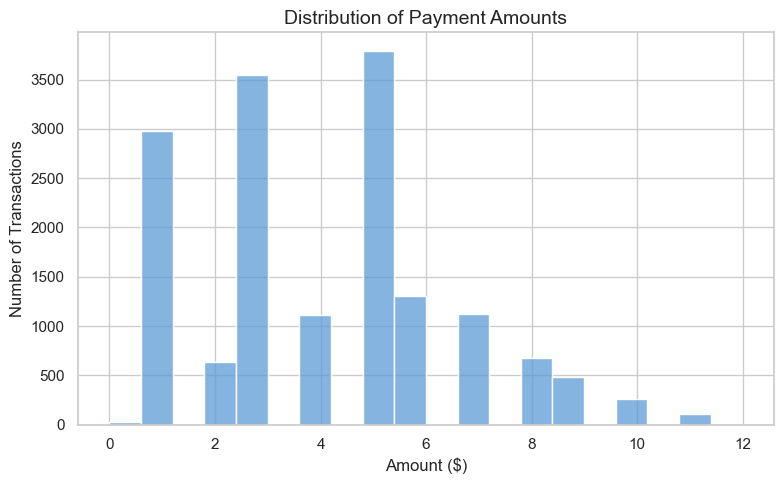

In [22]:
plt.figure(figsize=(8, 5))
sns.histplot(df_master['amount'], bins=20, color='#5B9BD5', edgecolor='white')
plt.title('Distribution of Payment Amounts', fontsize=14)
plt.xlabel('Amount ($)')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

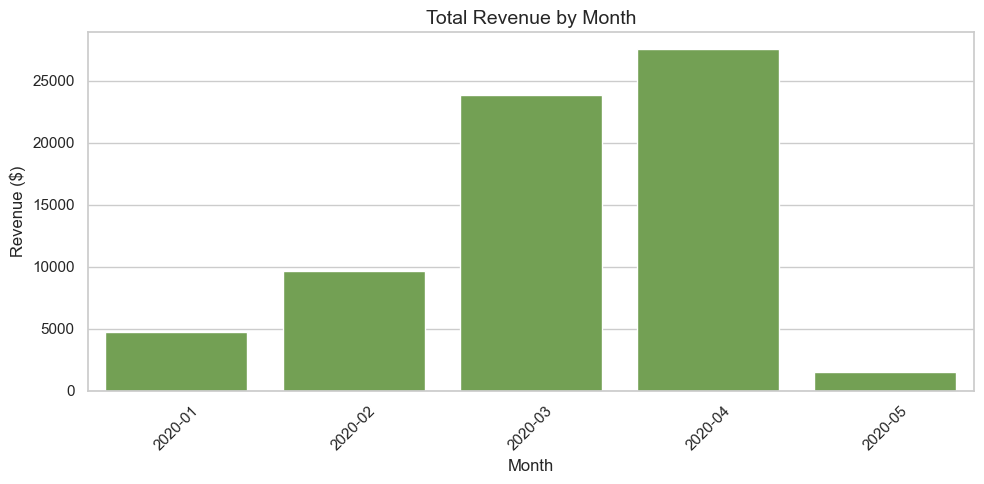

In [23]:
monthly_revenue = (
    df_master.groupby('payment_month')['amount']
    .sum()
    .reset_index()
)
monthly_revenue['payment_month'] = monthly_revenue['payment_month'].astype(str)

plt.figure(figsize=(10, 5))
sns.barplot(data=monthly_revenue, x='payment_month', y='amount', color='#70AD47')
plt.title('Total Revenue by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\dhanu\AppData\Local\Temp\ipykernel_7452\3887868524.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_master, x='rating', order=rating_order, palette='Set2')


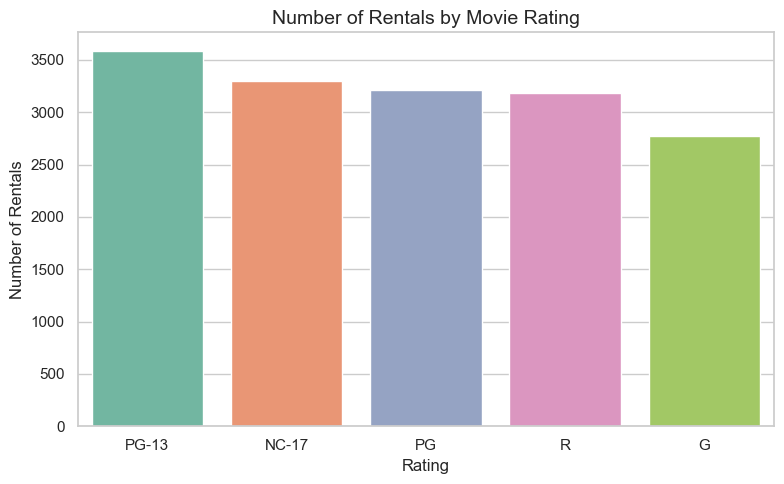

In [24]:
rating_order = df_master['rating'].value_counts().index

plt.figure(figsize=(8, 5))
sns.countplot(data=df_master, x='rating', order=rating_order, palette='Set2')
plt.title('Number of Rentals by Movie Rating', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Number of Rentals')
plt.tight_layout()
plt.show()

C:\Users\dhanu\AppData\Local\Temp\ipykernel_7452\1662324739.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='coolwarm')


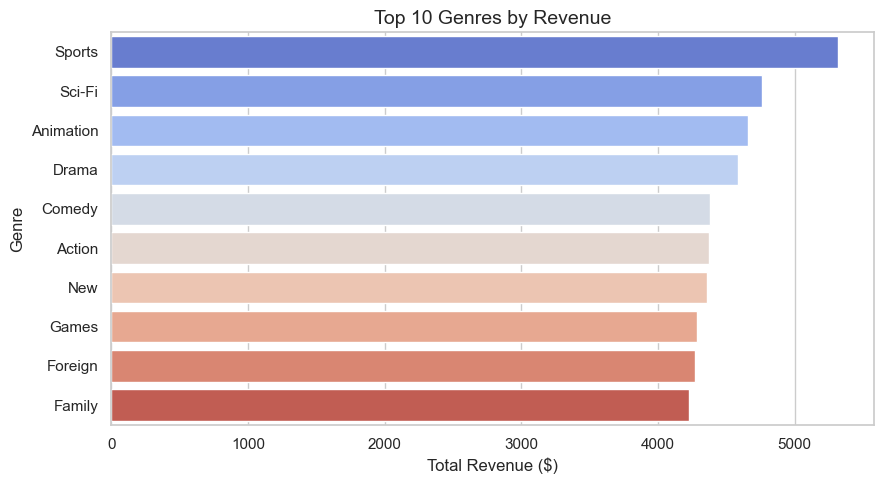

In [25]:
top_genres = revenue_by_category.head(10)

plt.figure(figsize=(9, 5))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='coolwarm')
plt.title('Top 10 Genres by Revenue', fontsize=14)
plt.xlabel('Total Revenue ($)')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

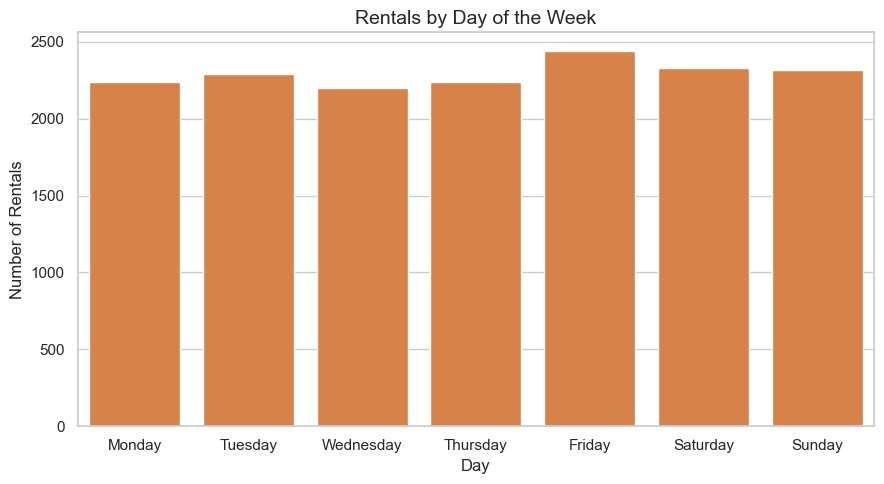

In [26]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

rentals_by_day = (
    df_master['rental_day_of_week']
    .value_counts()
    .reindex(day_order)
)

plt.figure(figsize=(9, 5))
sns.barplot(x=rentals_by_day.index, y=rentals_by_day.values, color='#ED7D31')
plt.title('Rentals by Day of the Week', fontsize=14)
plt.xlabel('Day')
plt.ylabel('Number of Rentals')
plt.tight_layout()
plt.show()